In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
class LinearRegressionAnalyzer:
  def __init__(self, dataset):
    self.dataset = dataset
    self.model = LinearRegression()
  def prepare_data(self):
    self.X = self.dataset[["Hours_Studied"]]
    self.y = self.dataset["Exam_Score"]
  def split_dataset(self):
    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
        self.X,
        self.y,
        test_size=0.2,
        random_state=42
    )
  def train_model(self):
    self.model.fit(self.X_train, self.y_train)
  def evaluate_model(self):
    self.predictions = self.model.predict(self.X_test)
    mse = mean_squared_error(self.y_test, self.predictions)
    r2 = r2_score(self.y_test, self.predictions)
    print("\nMODEL EVALUATION")
    print("-" * 40)
    print(f"Coefficient : {self.model.coef_[0]:.4f}")
    print(f"Intercept   : {self.model.intercept_:.4f}")
    print(f"MSE         : {mse:.4f}")
    print(f"R2 Score    : {r2:.4f}")
  def predict(self, hours):
    predicted_score = self.model.predict([[hours]])[0]
    print(f"\nPredicted Score for {hours} study hours = {predicted_score:.2f}")
  def visualize(self):
    x_values = self.X.values
    y_values = self.y.values
    regression_line = self.model.predict(self.X)
    plt.figure(figsize=(10, 6))
    plt.scatter(
        x_values,
        y_values,
        label="Actual Data"
    )
    plt.plot(
        x_values,
        regression_line,
        linewidth=2,
        label="Regression Line"
    )
    plt.title("Simple Linear Regression Analysis")
    plt.xlabel("Hours Studied")
    plt.ylabel("Exam Score")
    plt.legend()
    plt.grid(True)
    plt.show()

In [59]:
# ----------------------
# Dataset
# ----------------------
data = pd.DataFrame({
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Exam_Score": [35, 40, 50, 55, 65, 70, 75, 85, 90, 95]
})


MODEL EVALUATION
----------------------------------------
Coefficient : 6.7241
Intercept   : 29.2672
MSE         : 3.7102
R2 Score    : 0.9941

Predicted Score for 12 study hours = 109.96


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


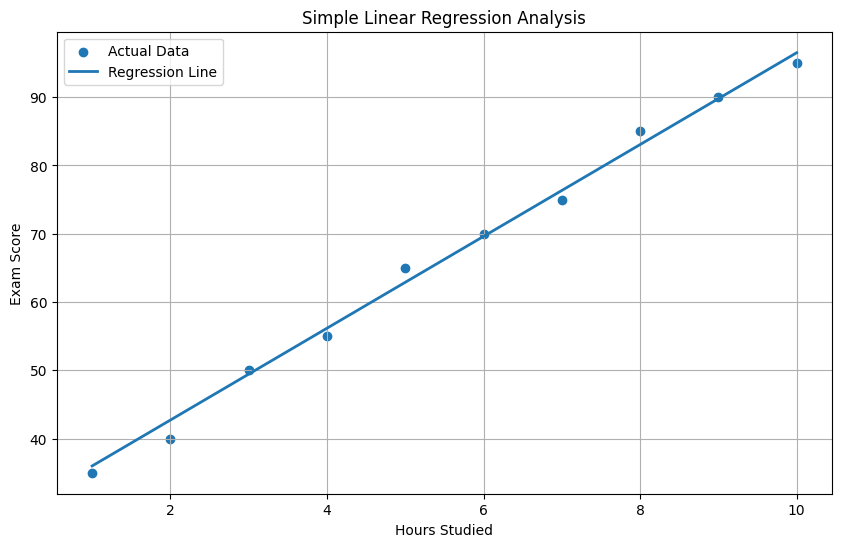

In [60]:
# ----------------------
# Workflow
# ----------------------
analysis = LinearRegressionAnalyzer(data)
analysis.prepare_data()
analysis.split_dataset()
analysis.train_model()
analysis.evaluate_model()
analysis.predict(12)
analysis.visualize()